In [1]:
import numpy
import scipy
from os.path import join
import matplotlib.pyplot as plt
import texplot
import matplotlib.ticker as mticker

# Imports from freealg
import freealg
from freealg import AlgebraicForm
from freealg.visualization import plot_flow, plot_mass, ridgeplot
from freealg.visualization._api_plot_util import _decimal_text, _k_pow2_formatter

# Plotting options
plot_dir = './plots'
save_filename = 'Umatrix64k'
latex = True

# Diffusion Model

Data's ESD replicates Fig 4 (right panel) of:

* [Why Diffusion Models Don’t Memorize: The Role of Implicit Dynamical Regularization in Training](https://openreview.net/pdf?id=BSZqpqgqM0)

The data is the matrix $\mathbf{U}$ in the above paper, here generated at the size $64K \times 64K$.

The input file loaded below (`Umatrix64k_eigs.npz`) contains a list of numpy arrays. Each array is the eigenvalues of a sumbatrix, ranging from the size $1K, 2K, 4K, \dots, 64K$.

Idx   Size   Repeat
---  -----   ------
0     1000       16
1     2000        8
2     4000        4
3     8000        2
4    16000        1
5    32000        1
6    64000        1

proc name: Intel(R) Xeon(R) Gold 6126 CPU @ 2.60GHz
num proc:  48
date:      2026-03-25 21:51:04 PDT



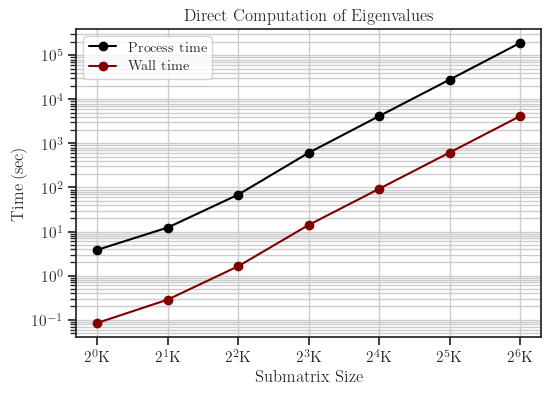

In [2]:
# Load input file
# filename = 'Umatrix64k_eigs_old.npz'
filename = 'Umatrix64k_eigs.npz'                      # float32
# filename = 'Umatrix64kf3.2n100d0.01t_eigs.npz'          # float64
dir_ = '/home/sia/work/scripts/free/Xperimental/hessian'
data = numpy.load(join(dir_, filename), allow_pickle=True)
out = data['out'].item()

# Extract variables
sizes = out['sizes']                 # List of sizes of the submatrices
repeats = out['repeats']             # Repeats of sampling
eigs_repeated = out['eigs']          # List of eigenvalues per each submatrix
eigs = out['eigs']          # List of eigenvalues per each submatrix
wall_times = out['wall_times']       # List of wall times taken to compute eigenvalues
proc_times = out['proc_times']       # List of CPU process times taken to compute eigenvalues
n, p = out['shape']                  # Dimension of the original matrix (largest matrix)
proc_name = out['proc_name']
num_proc = out['num_proc']
date = out['date']

# concatenate all repeats
max_repeat = 4
eigs = [None] * len(eigs_repeated)
for i in range(len(eigs_repeated)):
    rep_size = min(eigs_repeated[i].shape[0], max_repeat)
    eigs[i] = eigs_repeated[i][:rep_size, :].ravel()

# Sizes of submatrices
print('Idx   Size   Repeat')
print('---  -----   ------')
for i in range(sizes.size):
    print(f'{i:<2d}  {sizes[i]:>6d}  {repeats[i]:>7d}')
print('')
print(f'proc name: {proc_name}')
print(f'num proc:  {num_proc}')
print(f'date:      {date}')
print('')

# Plot wall and process times
with texplot.theme(use_latex=latex):
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(sizes, proc_times, '-o', color='black', label='Process time')
    ax.plot(sizes, wall_times, '-o', color='maroon', label='Wall time')
    ax.set_xlabel('Submatrix Size')
    ax.set_ylabel('Time (sec)')
    ax.set_title('Direct Computation of Eigenvalues')
    ax.legend(fontsize='small')
    ax.set_xscale('log', base=2)
    ax.xaxis.set_major_locator(mticker.LogLocator(base=2, subs=(1000/512.0,)))
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(_k_pow2_formatter))
    ax.set_yscale('log')
    ax.grid(True, which='both')
    plt.show()

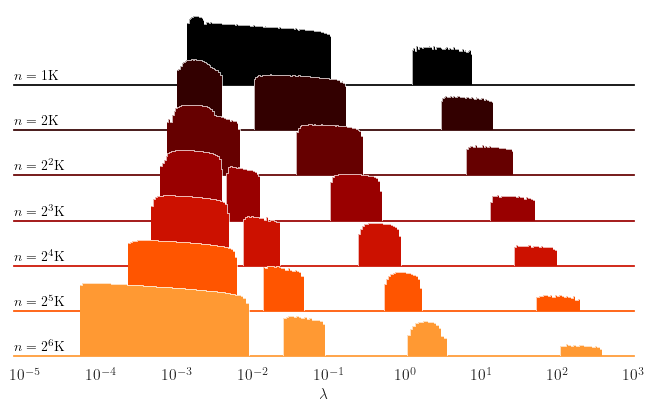

In [3]:
ridgeplot(sizes, eigs=eigs, log=True, scaley=False, hspace=-0.4,
          text_side='left', xlim=(7e-6, 1e3), figsize=(8, 4.5),
          label_mode='pow-int', latex=latex, title='',
          save=False, nbins=200)

# Fit Spectral Curve

In [3]:
# Index to choose the initial sub-matrix size
# start_idx = 2  # TEST
start_idx = 2

# Detect support from histogram
support = freealg.supp(eigs[start_idx], method='hist', tol=0, nbins=150, log=True)
print('\n------------------------------------------')
print('Support (detected from histogram):')
for i, supp in enumerate(support):
    print(f'\tInterval {i+1}: ({supp[0]:>9.4f}, {supp[1]:>9.4f})')

# Stieltjes options (Homotopy)
stieltjes_opt = dict(
    n_levels = 200,
    max_subdivide = 4,
    anchor_mode = 'empirical',
    anchor_y_min = 1e-4,  # 1e-5~1e-6 cause left bulks to fail
    anchor_y_max = 1,
    anchor_ratio = 0.01,  # 0.1~1 cause stieltjes_emp to not latch to poly roots
    # anchor_match_tol = numpy.inf,  # disables anchor retry
    # anchor_ratio_tol = numpy.inf,
    anchor_match_tol = 0.1,       # retry if init anchor not mathc roots
    anchor_ratio_tol = 0.9,
    anchor_retry_factor = 3.0     # factor to multiple anchor height in retrial
)

# Inverse Stieltjes (Plemelj)
inv_stieltjes_opt = dict(
    delta = 1e-6,
    delta_ladder_ratio = 2.0,
    delta_ladder_size = 4,
    delta_ladder_grid = 'linear',   # geometric, linear
    z_query_delta = 'const',       # const, linear
    method = 'chebfit',             # direct, polyfit, chebfit, poisson
    fit_degree = 2,
    reg = 0.0,
    fit_weight = 'small_delta',  # 'uniform, small_delta
)

# Smaller delta lowers the density baseline curve 1/x^2.
af = AlgebraicForm(eigs[start_idx],
                   support=support,
                   n=sizes[start_idx],
                   log=True,
                   dtype='complex128',
                   stieltjes_opt=stieltjes_opt,
                   inv_stieltjes_opt=inv_stieltjes_opt)

# We use deg_z = 1 since we guess the data is closely related to free Levy
# model, where deg_z is always 1. We also set _deg_m = 5 to have the capacity
# of representing 4 bulks once decompressed.
print('\n------------------------------------------')

# Combinations that work
# deg_m, deg_z = 6, 6
deg_m, deg_z = 8, 5

# deg_m, deg_z = 10, 5
# deg_m, deg_z = 9, 5
# deg_m, deg_z = 8, 4
# deg_m, deg_z = 7, 3
# deg_m, deg_z = 6, 3

coeffs = af.fit(
    deg_m, deg_z, reg=0,
    r_min=1.8, r_max=2.2, n_r=5,
    y_scale=1.0, gamma=1.0,
    n_samples=4096 // 2,
    # n_samples=4096,
    cut_eps=0.01,
    normalize=True, triangular=None,
    mu='auto',
    # mu=None,
    mu_reg=None, verbose=True)

# print('\n------------------------------------------')
# print('Support (estimated from polynomial):')
# est_supp = af.support()
# for i, supp in enumerate(est_supp):
#     print(f'\tInterval {i+1}: ({supp[0]:>9.4f}, {supp[1]:>9.4f})')

# print('\n------------------------------------------')
# print('Atoms (estimated from polynomial):')
# for i, atom in enumerate(af.atoms()):
#     print(f'\tAtom {i+1}. x: {atom[0]:>4.1e}, '
#           f'weight: {100.0*atom[1]:>4.1f}%')


------------------------------------------
Support (detected from histogram):
	Interval 1: (   0.0007,    0.0068)
	Interval 2: (   0.0374,    0.2753)
	Interval 3: (   5.8998,   28.3054)

------------------------------------------
fit residual max  : 3.2646e-04
fit residual 99.9%: 3.2564e-04

Coefficients (real)
+0.71057042 +0.12543182 +0.00535775 -0.00002815 +0.00000006 -0.00000000 +0.00000000 +0.00000000 +0.00000000 
+0.07181131 +0.91830339 +0.21542352 +0.01186707 -0.00004192 +0.00000006 -0.00000000 -0.00000000 -0.00000000 
-0.21206777 +0.23053875 +0.16442890 +0.07678571 +0.00620056 -0.00001447 +0.00000001 +0.00000000 +0.00000000 
+0.00544492 -0.47123307 +0.16405561 -0.02920091 +0.00016136 -0.00000012 -0.00000000 +0.00000000 -0.00000000 
+0.00010558 +0.01533307 -0.26036345 +0.00341166 -0.00001237 +0.00000001 +0.00000000 -0.00000000 +0.00000000 
+0.00000000 +0.00010558 +0.00992950 -0.00008119 +0.00000015 +0.00000000 -0.00000000 +0.00000000 +0.00000000 

Coefficients (imag) norm: 0.000

# DEBUG

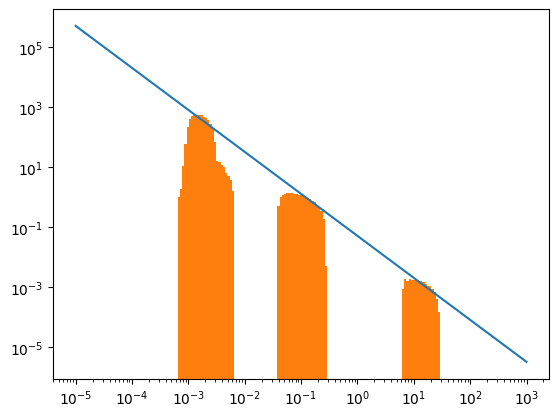

In [4]:
bins = numpy.geomspace(1e-5, 1e3, 200)
x = bins
f = 0.05 * x**(-1.4)
plt.plot(x, f)
plt.hist(eigs[start_idx], bins, density=True)
plt.xscale('log')
plt.yscale('log')
plt.show()

In [5]:
# Detect support from histogram
support = freealg.supp(eigs[start_idx], method='hist', tol=0, nbins=150, log=True)
print('\n------------------------------------------')
print('Support (detected from histogram):')
for i, supp in enumerate(support):
    print(f'\tInterval {i+1}: ({supp[0]:>9.4f}, {supp[1]:>9.4f})')


eig = eigs[start_idx]
masses = []

for a, b in support:
    mass = numpy.mean((eig >= a) & (eig <= b))
    masses.append(mass)

for j, (ab, mass) in enumerate(zip(support, masses), start=1):
    print(f'bulk {j}: interval={ab}, mass={mass:.6f}, percent={100*mass:.2f}%')

print('total mass:', sum(masses))


------------------------------------------
Support (detected from histogram):
	Interval 1: (   0.0007,    0.0068)
	Interval 2: (   0.0374,    0.2753)
	Interval 3: (   5.8998,   28.3054)
bulk 1: interval=(0.0006909190733197621, 0.006761123392981975), mass=0.800000, percent=80.00%
bulk 2: interval=(0.03740783915986226, 0.27525191067706894), mass=0.175000, percent=17.50%
bulk 3: interval=(5.8998084637473065, 28.305425820582585), mass=0.025000, percent=2.50%
total mass: 1.0


In [6]:
import numpy

support = [
    (0.0006909190733197621, 0.006761123392981975),
    (0.03740783915986226, 0.27525191067706894),
    (5.8998084637473065, 28.305425820582585),
]

masses = numpy.array([0.8, 0.175, 0.025], dtype=float)

# geometric centers of bulks
x_centers = numpy.array([numpy.sqrt(a*b) for a, b in support], dtype=float)

logx = numpy.log(x_centers)
logm = numpy.log(masses)

# fit log M = intercept + slope * log x
slope, intercept = numpy.polyfit(logx, logm, 1)

beta = -slope
C = numpy.exp(intercept)

print("x_centers =", x_centers)
print("slope     =", slope)
print("intercept =", intercept)
print(f"M(x) ~ {C:.4g} * x^(-{beta:.4f})")

x_centers = [2.16133966e-03 1.01472061e-01 1.29227161e+01]
slope     = -0.39866733455085607
intercept = -2.664526575193461
M(x) ~ 0.06963 * x^(-0.3987)


In [14]:
fac = masses ** (-0.25)
fac /= fac.max()          # weakest bulk gets factor 1

max_n_samples = 4096
bulk_n_samples = numpy.array([int(2 * round((max_n_samples * f) / 2)) for f in fac])

print('n_samples =', bulk_n_samples)

n_samples = [1722 2518 4096]


# Sample

In [8]:
from freealg._algebraic_form._continuation_algebraic import sample_z_joukowski
from freealg._algebraic_form._continuation_algebraic import filter_z_away_from_cuts
from freealg._geometric_form._continuation_genus0 import joukowski_z


# def sample_z_joukowski(support,
#                        n_samples=4096,
#                        r_min=1.8, r_max=2.2, n_r=5,
#                        y_scale=1.0, gamma=1.0,
#                        log=False, dtype=complex):

#     if numpy.isscalar(n_samples):
#         n_samples = numpy.tile(n_samples, len(support))

#     rs = numpy.linspace(r_min, r_max, n_r)

#     z_list = []
    
#     for i, supp in enumerate(support):
#         a, b = supp

#         if n_samples[i] % 2 != 0:
#             raise ValueError('n_samples should be even.')
            
#         n_half = n_samples[i] // 2
#         theta = numpy.pi * (numpy.arange(n_half) + 0.5) / n_half
        
#         for r_i in rs:
#             w = r_i * numpy.exp(1j * theta)
    
#             if log:
#                 u = joukowski_z(w, numpy.log(a), numpy.log(b))
                
#                 # Option 1: Log only along x axis
#                 Delta = numpy.log(b / a)
#                 x = numpy.exp(u.real)
#                 shape = u.imag / numpy.median(numpy.abs(u.imag))
#                 y = y_scale * (x ** gamma) * Delta * shape
#                 z = x + 1j * y
    
#                 # Option 2: Full log in z plane
#                 # z = numpy.exp(u)
#             else:
#                 z = joukowski_z(w, a, b)
    
#             z_list.append(z)
#             z_list.append(numpy.conjugate(z))

#     z_fit = numpy.concatenate(z_list, dtype=dtype)

#     return z_fit

In [28]:
# def filter_z_away_from_cuts(z, cuts, cut_eps=0.01, log=False):
#     """
#     Remove points that are too close to any real cut interval.

#     Parameters
#     ----------
#     z : array_like
#         Complex sample points.

#     cuts : sequence of (a, b)
#         Real cut intervals.

#     cut_eps : float
#         Fraction of cut width used as the distance threshold.

#         * log=False: threshold is ``cut_eps * (b - a)``, where ``(b - a)`` is the
#           linear width of the cut interval.

#         * log=True: threshold is ``cut_eps * log(b / a)``, where ``log(b / a)`` is the
#           logarithmic width of the cut interval.

#     log : bool
#         If True, use a cut-dependent relative threshold:
#             eps_j = cut_eps * sqrt(a*b)
#         If False, use:
#             eps_j = cut_eps

#     Returns
#     -------
#     z_filt : ndarray
#         Filtered points.
#     """

#     z = numpy.asarray(z).ravel()

#     if cut_eps is None or cut_eps <= 0:
#         return z

#     x = z.real
#     y = numpy.abs(z.imag)

#     keep = numpy.ones(z.size, dtype=bool)

#     for a, b in cuts:
#         if log:
#             # log-aware coordinates: horizontal = log x, vertical = y/x
#             dx = numpy.where(x < a, numpy.log(a / x),
#                  numpy.where(x > b, numpy.log(x / b), 0.0))
#             dy = numpy.abs(numpy.arctan2(y, x))
#             dist = numpy.sqrt(dx**2 + dy**2)
#             eps_j = cut_eps * numpy.log(b / a)
#         else:
#             # ordinary linear geometry in z-plane
#             dx = numpy.where(x < a, a - x,
#                  numpy.where(x > b, x - b, 0.0))
#             dy = y
#             dist = numpy.sqrt(dx**2 + dy**2)
#             eps_j = cut_eps * (b - a)
        
#         keep &= (dist > eps_j)

#     return z[keep]

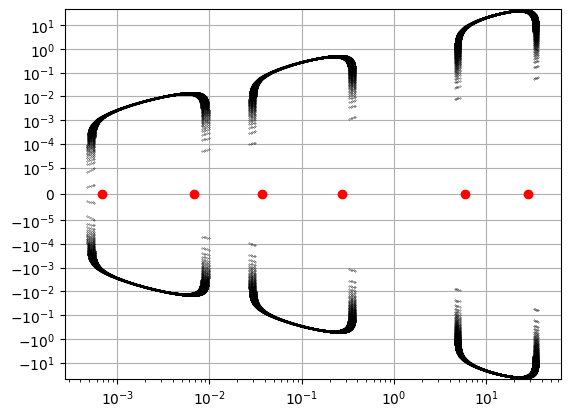

In [15]:
r_min, r_max, n_r = 1.8, 2.2, 5

y_scale = 1
gamma = 1 #-0.39

n_samples = 4096 // 2
cut_eps = 0.01

possible_supp = af.supp
# possible_supp = [af.broad_supp]

edges = []
for sup in possible_supp:
    a, b = sup
    edges.append([a, b])

z_fit = sample_z_joukowski(possible_supp,
                           # n_samples=n_samples,
                           n_samples=bulk_n_samples,
                           r_min=r_min, r_max=r_max, n_r=n_r,
                           y_scale=y_scale, gamma=gamma,
                           log=True)

z_fit = filter_z_away_from_cuts(z_fit, possible_supp, cut_eps=cut_eps, log=True)

edges = numpy.concatenate(edges, dtype=complex)

plt.plot(z_fit.real, z_fit.imag, 'o', color='black', markersize=0.25)
plt.plot(edges.real, edges.imag, 'o', color='red')
plt.xscale('log')
plt.yscale('symlog', linthresh=1e-5)
plt.grid()
plt.show()

In [17]:
from freealg._algebraic_form._continuation_algebraic import fit_polynomial_relation
from freealg._algebraic_form._stieltjes_poly3 import StieltjesPoly

# mu = 'auto'
mu = None
reg = 0.0
# triangular = None
triangular = 'upper'
normalize = True
mu_reg = None

# deg_m, deg_z = 8, 5
# deg_m, deg_z = 6, 6
# deg_m, deg_z = 6, 6
deg_m, deg_z = 7, 7


weights = None
# weights = numpy.ones_like(xx).ravel()
# weights = (numpy.log(xx)).ravel()
# weights = ((z_fit.real)**(-1)).ravel()
# weights = weights / numpy.mean(weights)

# Automatically add mu constraints from eigenvalues
if mu == 'auto':
    if af.eig is not None:
        mu_0 = 1.0
        mu_1 = numpy.mean(af.eig)
        mu_2 = numpy.mean(af.eig**2)
        mu = [mu_0, mu_1, mu_2]
    else:
        mu = None

# Fitting (w_inf = None means adaptive weight selection)
m1_fit = af._stieltjes_emp(z_fit)
af.coeffs, fit_metrics = fit_polynomial_relation(
        z_fit, m1_fit, s=deg_m, deg_z=deg_z, ridge_lambda=reg,
        weights=weights, triangular=triangular, normalize=normalize,
        mu=mu, mu_reg=mu_reg)

# Stieltjes transform from fitted polynomial (not from empirical eigs)
af._stieltjes_poly = StieltjesPoly(
    af.coeffs, stieltjes_opt=af.stieltjes_opt,
    stieltjes_emp=af._stieltjes_emp)

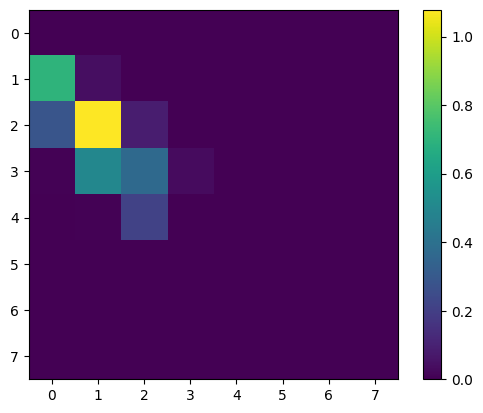

In [27]:
p = plt.imshow(numpy.abs(af.coeffs.real))
plt.colorbar(p)
plt.show()

In [25]:
numpy.abs(af.coeffs.real)

array([[3.55339649e-03, 3.69504374e-04, 2.42381646e-05, 1.79368902e-07,
        4.95891686e-10, 6.11493599e-13, 2.99176902e-16, 6.00344110e-21],
       [7.02370441e-01, 4.12266706e-02, 2.30045695e-03, 5.58929117e-05,
        3.01265919e-07, 5.69488551e-10, 3.84275371e-13, 3.07820679e-17],
       [2.85332139e-01, 1.07847265e+00, 8.44933638e-02, 2.53579267e-03,
        3.08847425e-05, 1.22056741e-07, 1.40545212e-10, 1.63795510e-14],
       [8.17993800e-03, 5.00698888e-01, 3.67539918e-01, 3.05449384e-02,
        4.39937334e-04, 2.11535557e-06, 4.28660348e-09, 3.13270189e-12],
       [5.55374352e-04, 6.72069862e-03, 2.13890312e-01, 2.18609250e-03,
        3.17120439e-06, 2.78059182e-08, 1.03281342e-10, 9.87136883e-14],
       [8.71104559e-06, 5.58912988e-04, 1.62391731e-03, 3.04411575e-05,
        2.11198355e-07, 6.97412181e-10, 1.10955462e-12, 6.84228607e-16],
       [3.10209875e-15, 8.71104613e-06, 1.27622660e-07, 7.62527169e-10,
        2.42384584e-12, 4.31157739e-15, 4.04759712e-18, 1.

In [26]:
numpy.abs(af.coeffs.imag)

array([[0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.]])

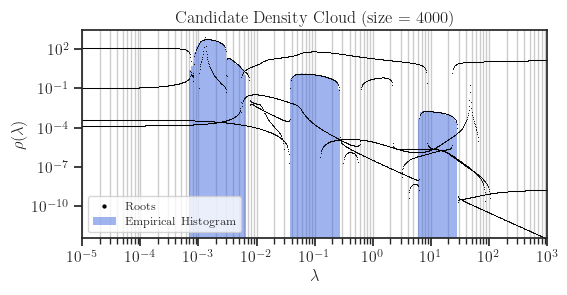

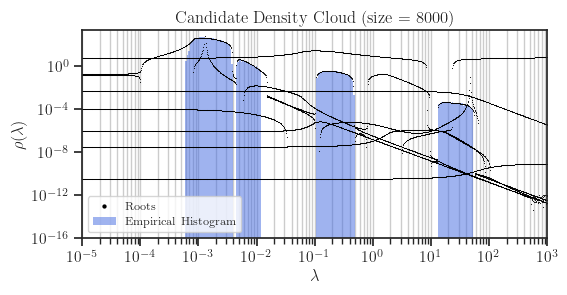

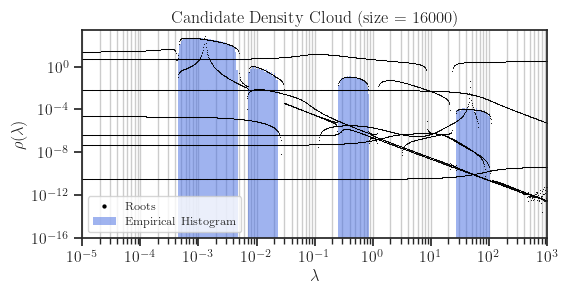

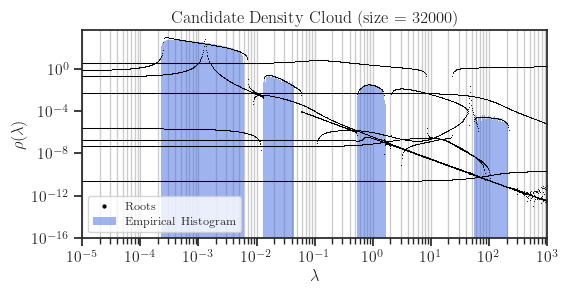

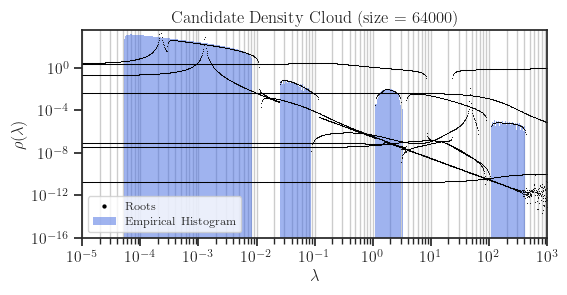

In [18]:
# Check if the density plotted above is formed by correct roots. For this,
# we plot all possible roots below.
x_min = 1e-5
x_max = 1e3
x_highres = numpy.geomspace(x_min, x_max, 1000)

for idx in range(start_idx, sizes.size):
    af.candidates(
        size=sizes[idx],
        x=x_highres,
        eig=eigs[idx],
        delta=None, markersize=0.6, latex=latex)

In [9]:
# Stieltjes options (Homotopy)
stieltjes_opt = dict(
    n_levels = 200,
    max_subdivide = 5,
    anchor_mode = 'empirical',
    anchor_y_min = 1e-4,  # 1e-5~1e-6 cause left bulks to fail
    anchor_y_max = 10,
    anchor_ratio = 1,  # 0.1~1 cause stieltjes_emp to not latch to poly roots
    # anchor_match_tol = numpy.inf,  # disables anchor retry
    # anchor_ratio_tol = numpy.inf,
    anchor_match_tol = 0.1,       # retry if init anchor not mathc roots
    anchor_ratio_tol = 0.9,
    anchor_retry_factor = 3.0,     # factor to multiple anchor height in retrial
    log_scale = True
)

inv_stieltjes_opt = dict(
    delta = 1e-6,
    delta_ladder_ratio = 2.0,
    delta_ladder_size = 4,
    delta_ladder_grid = 'linear',   # geometric, linear
    z_query_delta = 'const',       # const, linear
    method = 'chebfit',             # direct, polyfit, chebfit, poisson
    fit_degree = 2,
    reg = 0.0,
    fit_weight = 'small_delta',  # 'uniform, small_delta
)

af.stieltjes_opt = stieltjes_opt
af.inv_stieltjes_opt = inv_stieltjes_opt

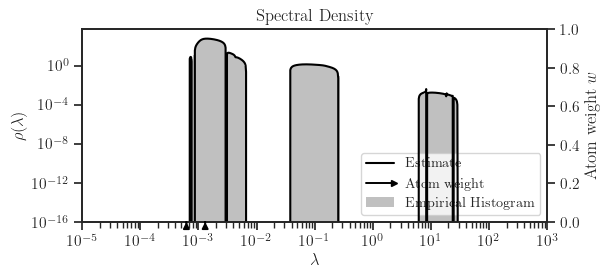


Mass: 1.01270315


In [10]:
# Plot density
x_min = 1e-5
x_max = 1e3
x0 = numpy.geomspace(x_min, x_max, 1000)
rho0 = af.density(x0, plot=True, latex=latex)

# Check mass (at start size)
print('')
mass = numpy.trapz(rho0, x0)
print(f'Mass: {mass:0.8f}')

Support (estimated from polynomial):
	Interval 1: (   0.0009,    0.0063)
	Interval 2: (   0.0390,    0.2692)
	Interval 3: (   5.9599,   28.0422)


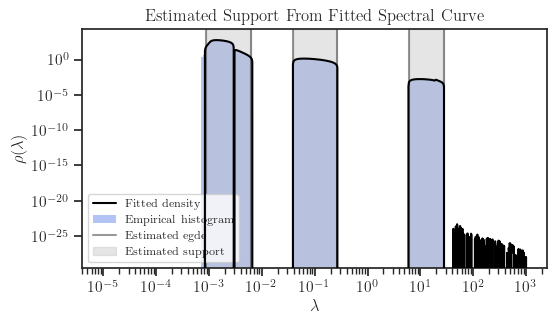

In [41]:
print('Support (estimated from polynomial):')

est_supp = af.support(refine=False, resplit_density=4, merge_threshold=0.1)

for i, supp in enumerate(est_supp):
    print(f'\tInterval {i+1}: ({supp[0]:>9.4f}, {supp[1]:>9.4f})')

with texplot.theme(use_latex=latex):
    alpha = 0.4
    fig, ax = plt.subplots(figsize=(6, 3.1))
    ax.plot(x0, rho0, color='black', zorder=10, label='Fitted density')
    
    bins = numpy.geomspace(
        numpy.min(eigs[start_idx]), numpy.max(eigs[start_idx]), 150)
    ax.hist(eigs[start_idx], bins, density=True,color='royalblue',
            alpha=0.4, zorder=1, edgecolor='none',
            label='Empirical histogram')
    
    for i in range(len(est_supp)):
        label = 'Estimated egde' if i == 0 else ''
        ax.axvline(est_supp[i][0], linestyle='-', color='black', alpha=alpha, label=label)
        ax.axvline(est_supp[i][1], linestyle='-', color='black', alpha=alpha)
    
        label = 'Estimated support' if i == 0 else ''
        ax.axvspan(est_supp[i][0], est_supp[i][1], color='silver', alpha=alpha, label=label)
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    # ax.set_xlim([x[0], x[-1]])
    ax.set_xlabel(r'$\lambda$')
    ax.set_ylabel(r'$\rho(\lambda)$')
    ax.legend(fontsize='x-small', loc='lower left')
    ax.set_title('Estimated Support From Fitted Spectral Curve')
    plt.show()

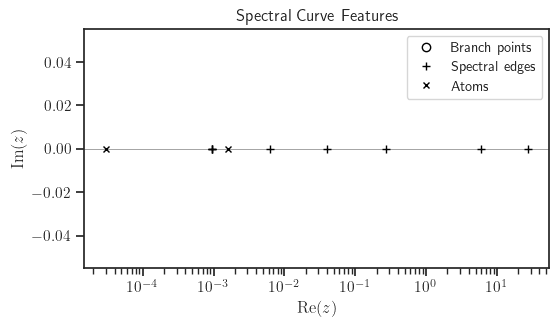


i   Branch Points        Spectral Edge
--  -------------------  -------------


In [125]:
# Branch points
bp = af.branch_points(tol=1e-16, real_tol=1e-16, plot=True, latex=latex)

# A branch point on real axis is a candidate to also be a spectral edge.
# Those with near zero imaginary part are flagged as maybe a spectral edge.
print('\ni   Branch Points        Spectral Edge')
print('--  -------------------  -------------')
for i in range(bp.size):
    print(f'{i+1}   {bp[i].real:>+8.4f}{bp[i].imag:>+5.3e}i', end='  ')
    if numpy.abs(bp[i].imag) < 1e-14:
        print('Maybe')
    else:
        print('No')

# Free Decompression

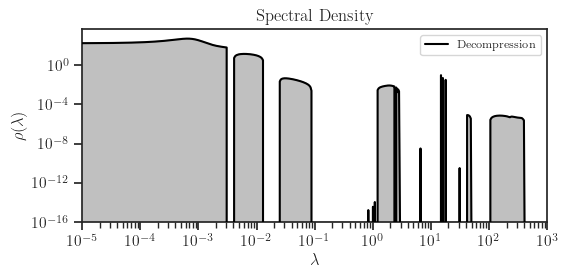

In [515]:
# Choosing the largest sub-matrix size to decompress to
# end_idx = sizes.size - 1
end_idx = 6

# Subset of sizes to apply free decompression
fd_sizes = sizes[start_idx:end_idx+1]

# x span of decompression
x_min = 1e-5
x_max = 1e3
x = numpy.geomspace(x_min, x_max, 500)

newton_opt = dict(
    dt_max=0.01,
    tol=1e-8,
    max_iter=1000,
    parallel=True,
    n_jobs=8,
    log_mode=True,
)

# Using method of characteristics (MoC) with 2x2 Newton and
# predictor/corrector (PC) to stabilize and speedup convergence
rho, x, atoms = af.decompress(
    fd_sizes, x=x, method='moc', min_n_times=100,
    newton_opt=newton_opt, return_atoms=True, atom_eps=0.0,
    verbose=False, plot=True, latex=latex)

Plot saved to "/home/sia/work/github/freealg/notebooks/./plots/Umatrix64k-flow.pdf".


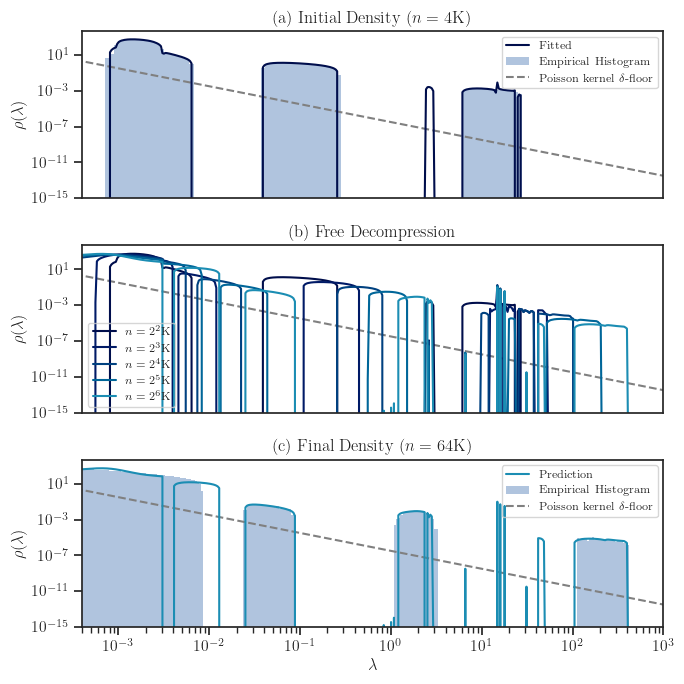

In [516]:
plot_flow(fd_sizes, x, rho, eigs[start_idx], eigs[end_idx], delta=af.delta,
          xlim=(4e-4, 1e3),
          ylim=(1e-15, 5e3),
          # ylim=(1e-8, 5e3),
          nbins=(100, 300),
          share_ax=True,
          layout='vertical',
          title='Free Decompression',
          cmap=plt.cm.ocean,
          c_range=(0.3, 0.7),
          hist_color='lightsteelblue',
          label_mode='pow-int',
          log=True,
          latex=latex,
          save=join(plot_dir, save_filename + '-flow.pdf'))

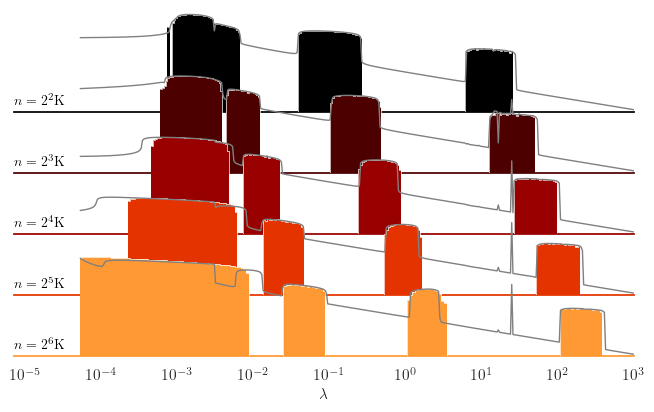

In [498]:
mask = x > numpy.min(eigs[end_idx])
ridgeplot(sizes[start_idx:end_idx+1], x=x[mask], rho=rho[:, mask],
          eigs=eigs[start_idx:end_idx+1],
          log=True, scaley=False, hspace=-0.4, rho_color='gray',
          text_side='left', xlim=(7e-6, 1e3), figsize=(8, 4.5),
          label_mode='pow-int', latex=latex, save=False, nbins=200)

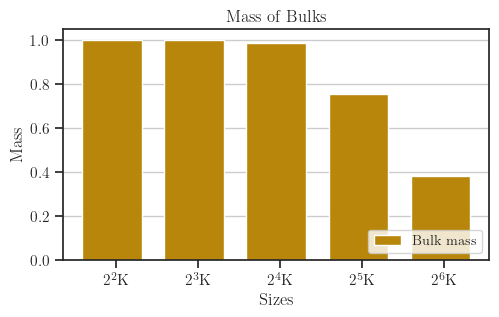

In [14]:
plot_mass(fd_sizes, x, rho, atoms=None, log_x=True, gap=0.7, latex=latex,
          save=False)

In [7]:
t_cusp = numpy.linspace(0, 4, 100)
cusps = af.cusp(t_cusp)

print('Cusps:')
for cusp in cusps:
    x_cusp, t_cusp = cusp
    print(f'\tx: {x_cusp:>0.3f}, t: {t_cusp:>0.3f}')

if len(cusps) > 0:
    x_cusp, t_cusp = cusps[0]
else:
    x_cusp, t_cusp = None, None

Cusps:


In [10]:
end_idx = 6
fd_sizes = sizes[start_idx:end_idx+1]

t_final = numpy.log(sizes[end_idx] / sizes[start_idx])
t = numpy.linspace(0, t_final, 500)

complex_edges, real_merged_edges, active_k = af.edge(
    t, dt_max=0.01, max_iter=100, tol=1e-12)

INSIDE edge(): complex_edges[:5,0].real = [0.00083062 0.00082643 0.00082223 0.000818   0.00081376]
INSIDE edge(): any nan col0? False
OUTSIDE edge(): complex_edges[:5,0].real = [0.00083062 0.00082643 0.00082223 0.000818   0.00081376]


In [11]:
complex_edges[:10, :].real

array([[8.30615349e-04, 3.02268894e-03, 3.02268894e-03, 6.57466533e-03,
        3.84415929e-02, 2.73067448e-01, 5.85069210e+00, 2.78326313e+01],
       [8.26432079e-04, 3.03011435e-03, 3.03011435e-03, 6.60597241e-03,
        3.87962353e-02, 2.74233733e-01, 5.88553191e+00, 2.79775738e+01],
       [8.22228014e-04, 3.03758540e-03, 3.03758540e-03, 6.63745295e-03,
        3.91534868e-02, 2.75405956e-01, 5.92056644e+00, 2.81233155e+01],
       [8.18003009e-04, 3.04510226e-03, 3.04510226e-03, 6.66910793e-03,
        3.95133625e-02, 2.76584150e-01, 5.95579678e+00, 2.82698610e+01],
       [8.13756918e-04, 3.05266512e-03, 3.05266512e-03, 6.70093834e-03,
        3.98758780e-02, 2.77768349e-01, 5.99122401e+00, 2.84172148e+01],
       [8.09489596e-04, 3.06027416e-03, 3.06027416e-03, 6.73294514e-03,
        4.02410485e-02, 2.78958585e-01, 6.02684922e+00, 2.85653813e+01],
       [8.05200897e-04, 3.06792958e-03, 3.06792958e-03, 6.76512935e-03,
        4.06088897e-02, 2.80154893e-01, 6.06267351e+00, 2.

In [12]:
from matplotlib.collections import PolyCollection

# ===========
# fill  bulks
# ===========

def fill_bulks(ax, t, edges, color, alpha=0.05, zorder=-2, width_tol=1e-12):
    """
    Seam-free fill for multiple bulks, generic 2k-column edges.
    Works as long as the number of *active bulks* does not change between
    consecutive time samples. (Insert cusp times into t to ensure that.)
    """
    t = numpy.asarray(t, dtype=float)
    E = numpy.asarray(edges, dtype=float)

    polys = []

    def add_strip(y0, y1, xL0, xR0, xL1, xR1):
        if not (numpy.isfinite(xL0) and numpy.isfinite(xR0) and numpy.isfinite(xL1) and numpy.isfinite(xR1)):
            return
        if (xR0 - xL0) <= width_tol or (xR1 - xL1) <= width_tol:
            return
        polys.append([(xL0, y0), (xR0, y0), (xR1, y1), (xL1, y1)])

    for i in range(len(t) - 1):
        e0 = E[i, :]
        e1 = E[i + 1, :]

        f0 = e0[numpy.isfinite(e0)]
        f1 = e1[numpy.isfinite(e1)]

        # Need complete pairs
        if (len(f0) % 2) != 0 or (len(f1) % 2) != 0:
            continue

        # If bulks count changes inside this step, skip (avoid wrong pairing)
        if len(f0) != len(f1):
            continue

        f0 = numpy.sort(f0)
        f1 = numpy.sort(f1)

        y0 = t[i]
        y1 = t[i + 1]

        nb = len(f0) // 2
        for j in range(nb):
            xL0, xR0 = f0[2*j], f0[2*j + 1]
            xL1, xR1 = f1[2*j], f1[2*j + 1]
            add_strip(y0, y1, xL0, xR0, xL1, xR1)

    if not polys:
        return

    coll = PolyCollection(
        polys,
        facecolors=[color],
        edgecolors="none",
        closed=True,
        alpha=alpha,
        zorder=zorder)

    ax.add_collection(coll)

Plot saved to "/home/sia/work/github/freealg/notebooks/./plots/Umatrix64k-edge.pdf".


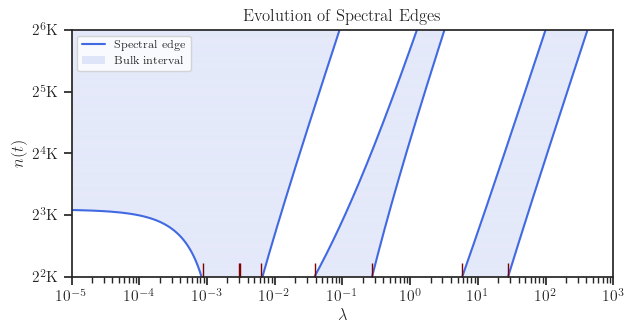

In [14]:
import matplotlib

# =============
# plot annotate
# =============

def plot_edges(complex_edges, real_merged_edges, sizes=None, edge_color='royalblue',
               alpha=0.1, fill_color='royal_blue', figsize=None, annotate=False, xlim=None, log=False,
               flip_y=False):
    """
    """
    
    # k = len(support)
    k = real_merged_edges.shape[1] // 2
    
    with texplot.theme(use_latex=True):

        if figsize is None:
            figsize = (6.5, 3.5)
            
        fig, ax = plt.subplots(figsize=figsize)
                               
        for j in range(k):
            a_r = real_merged_edges[:, 2*j + 0]
            b_r = real_merged_edges[:, 2*j + 1]
    
            a_c = complex_edges[:, 2*j + 0].real
            b_c = complex_edges[:, 2*j + 1].real

            if sizes is None:
                t_ = t
            else:
                t_ = sizes[0] * numpy.exp(t)
            
            # Plot spectral edges with solid lines
            label = 'Spectral edge' if j == 0 else ''
            ax.plot(a_r, t_, color=edge_color, label=label)
            ax.plot(b_r, t_, color=edge_color)
    
            # Plot ghost edges with dashed lines
            # m_a = numpy.isnan(a_r)
            # m_b = numpy.isnan(b_r)
            # ax.plot(a_c[m_a], t[m_a], '--', color=colors[j], alpha=0.25, zorder=-1)
            # ax.plot(b_c[m_b], t[m_b], '--', color=colors[j], alpha=0.25, zorder=-1)
    
            # Fill between (does not work with bifurcation, use fill_split_bulk)
            # ax.fill_betweenx(t, a_c, b_c, color=colors[j], alpha=0.05, zorder=-2)
            
            # --------
            # Plot I_j
            # --------
    
            if annotate:
                t_mid = 0.5 * (t[-1] - t_cusp) + t_cusp if 't_cusp' in globals() else 0.75 * t[-1]
                # t_mid = 0.8 * t[-1]
                j_mid = int(numpy.argmin(numpy.abs(t - t_mid)))
                
                ax.annotate('', xy=(float(b_r[j_mid]), t[j_mid]), xytext=(float(a_r[j_mid]), t[j_mid]),
                            arrowprops=dict(arrowstyle='<->', color='gray', lw=1.2))
                
                ax.text(0.5 * (float(a_r[j_mid]) + float(b_r[j_mid])), t[j_mid] + 0.03 * (t[-1] - t[0]),
                        fr'$I_{{{j+1}}}(t)$',
                        color='gray', ha='center', va='bottom', fontsize=11)
    
        # Fill between edges includign the bifurcated egdes # TEST
        fill_bulks(ax, t_, real_merged_edges, color=fill_color, alpha=alpha, zorder=-2)
    
        # ----------------
        # Plot I_1 cup I_2
        # ----------------
    
        if annotate:
            a_all = real_merged_edges[:, 0]
            b_all = real_merged_edges[:, -1]
        
            t_mid2 = 0.45 * min(t_cusp, t[-1]) if 't_cusp' in globals() else 0.45 * t[-1]
            j_mid2 = int(numpy.argmin(numpy.abs(t - t_mid2)))
            
            ax.annotate('', xy=(b_all[j_mid2], t[j_mid2]), xytext=(a_all[j_mid2], t[j_mid2]),
                        arrowprops=dict(arrowstyle='<->', color='gray', lw=1.2))
            
            ax.text(0.58 * (a_all[j_mid2] + b_all[j_mid2]), t[j_mid2] + 0.03 * (t[-1] - t[0]),
                    # r'$I_1(t) \cup I_2(t)$',
                    r'$I(t), \quad t < t_{\ast}$',
                    color='gray', ha='center', va='bottom', fontsize=11)

        # ---------------------
        # Initial edges
        if af.est_supp is not None:
            for edge_a, edge_b in af.est_supp:
                plt.plot(edge_a, t_[0], '|', color='maroon', markersize=20)
                plt.plot(edge_b, t_[0], '|', color='maroon', markersize=20)
    
        # ---------------------
    
        # Cusp
        if (annotate is True) and ('t_cusp' in globals()):
            ax.plot(x_cusp, t_cusp, 'o', color='black', markersize=4)
            ax.text(x_cusp + 0.12, t_cusp - 0.05, r'$(x_{\ast}, t_{\ast})$', fontsize=11)
    
        ax.set_xlim([x_min, x_max])
        ax.set_ylim([t_[0], t_[-1]])
        ax.set_xlabel(r'$\lambda$')
        ax.set_title(r'Evolution of Spectral Edges')
        
        h, l = ax.get_legend_handles_labels()
        h.append(matplotlib.patches.Patch(
            facecolor=fill_color, alpha=alpha, edgecolor='none'))
        l.append('Bulk interval')
        ax.legend(h, l, fontsize='x-small')

        if sizes is not None:
            ax.set_ylabel(r'$n(t)$')
        else:
            ax.set_ylabel(r'$t$')

        if log:
            ax.set_xscale('log')

            if sizes is not None:
                ax.set_yscale('log', base=2)

        if sizes is not None:
            ax.yaxis.set_major_locator(mticker.LogLocator(base=2, subs=(1000/512.0,)))
            ax.yaxis.set_major_formatter(mticker.FuncFormatter(_k_pow2_formatter))
            
        if xlim is not None:
            ax.set_xlim(xlim)

        if flip_y:
            ax.invert_yaxis()
        
        plt.tight_layout()
    
        save_full_filename = join(plot_dir, save_filename + '-edge.pdf')
        texplot.show_or_save_plot(plt, default_filename=save_full_filename,
                                  transparent_background=True, dpi=200,
                                  show_and_save=True, verbose=True)

# ----------------

plot_edges(complex_edges, real_merged_edges, sizes=fd_sizes,
           edge_color='royalblue', fill_color='royalblue', alpha=0.14,
           # edge_color='black', fill_color='gray', alpha=0.2,
           figsize=None, annotate=False, xlim=(1e-5, 1e3), log=True,
           flip_y=False)

In [20]:
af.est_supp

[(0.0008807767366105077, 0.002974088163575854),
 (0.003025512170692908, 0.006337487695253449),
 (0.03878090732457721, 0.27306832161970895),
 (5.850692573864126, 28.08709926860469)]